In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Kalman_filter import KalmanFilter

In [2]:
# simulation params
m = 1
F = 1
time_sec = 100  # 100 seconds
fs = 1  # samples count per second
angle = 45
mu0 = np.array([0.0, 1.0])
cov0 = np.array([[0.1, 0], [0, 0.1]])

x_true = np.array([0.0, 0.8])
u0 = np.array([F / m * np.cos(angle), F / m * np.sin(angle)])
z0 = np.random.normal(loc=0.0, scale=1.0, size=mu0.shape)

R = np.array([[0.01, 0], [0, 0.01]])  # ковариационная матрица модели
C = np.array([[1, 0], [0, 1]])
Q = np.array([[0.5, 0], [0, 0.5]])  # ковариационная матрица измерений

In [3]:
# model set
A = np.array([[1, 1 / fs], [0, 1]])
B = np.array([[(1 / fs) ** 2 / 2, 0], [0, 1 / fs]])

model = "uniform_accel"

In [4]:
kalman = KalmanFilter(mu0, cov0, u0, z0)
res = kalman.simulate(A, B, C, Q, R, x_true, time_sec, fs, model, False)

In [5]:
states = [res['states'][i][0] for i in range(len(res['states']))]
true_states = [res['true_states'][i][0] for i in range(len(res['true_states']))]

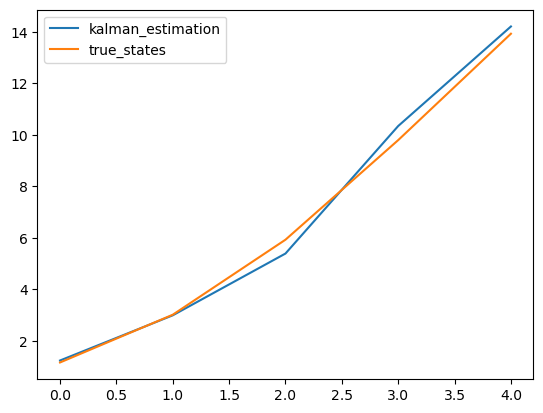

In [6]:
plt.plot(states[:5], label='kalman_estimation')
plt.plot(true_states[:5], label='true_states')
plt.legend()

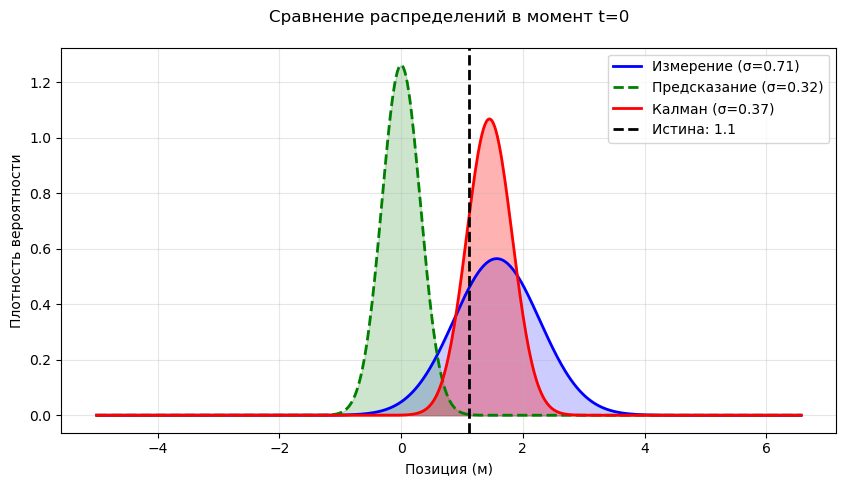

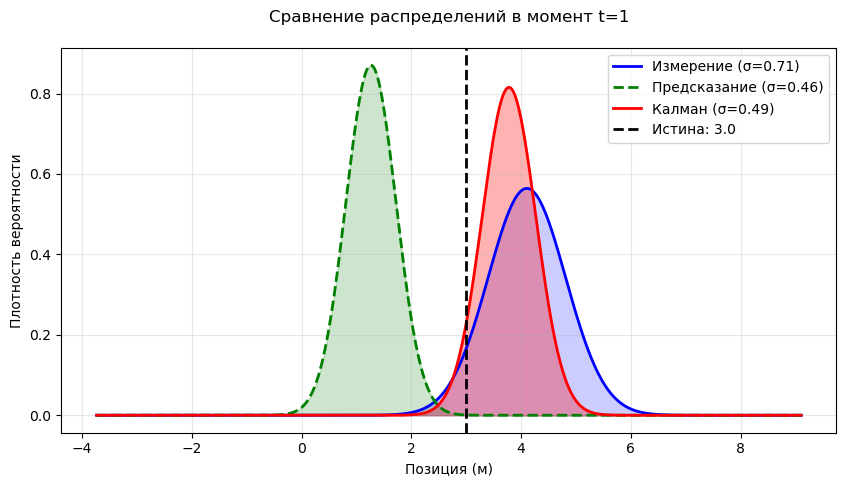

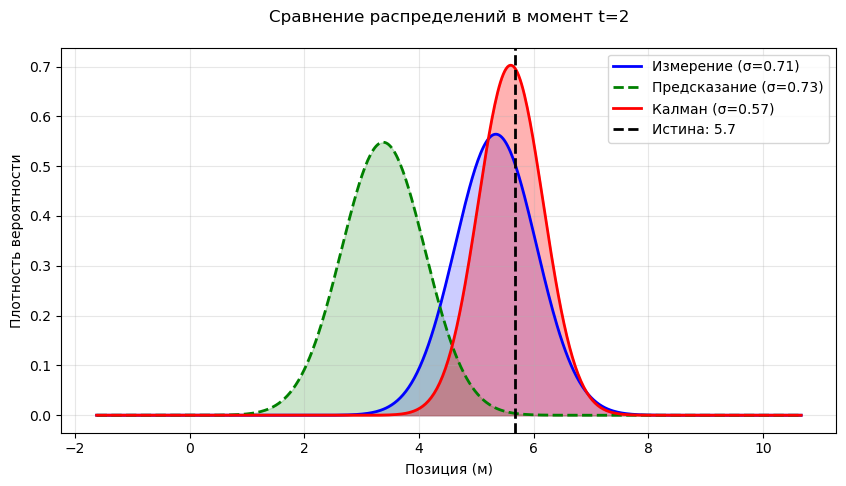

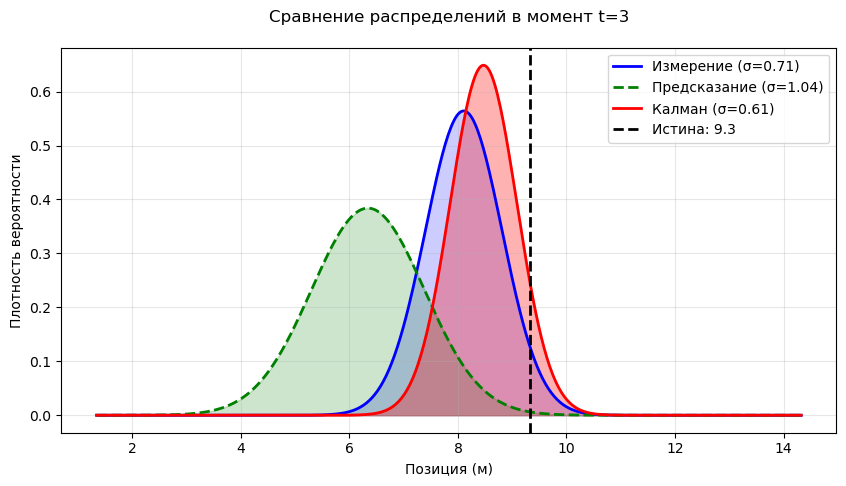

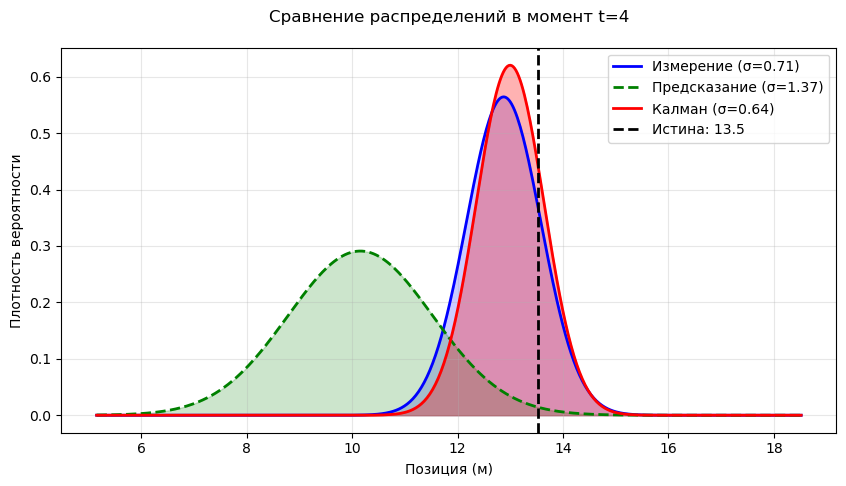

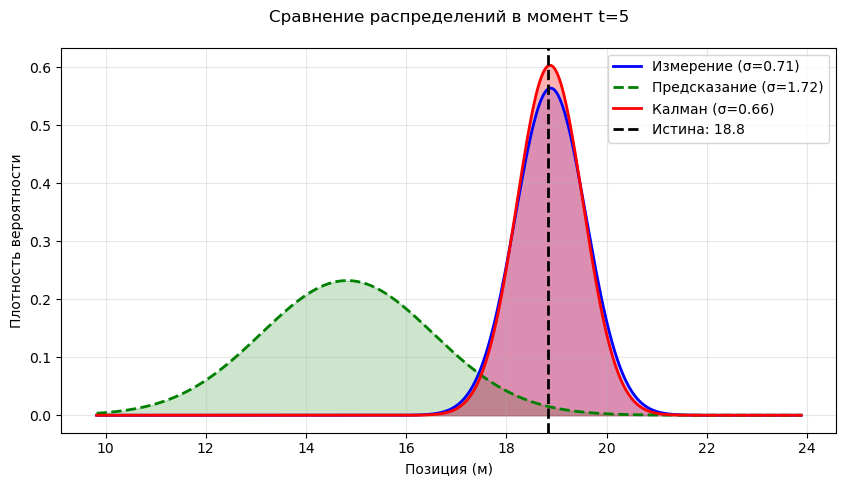

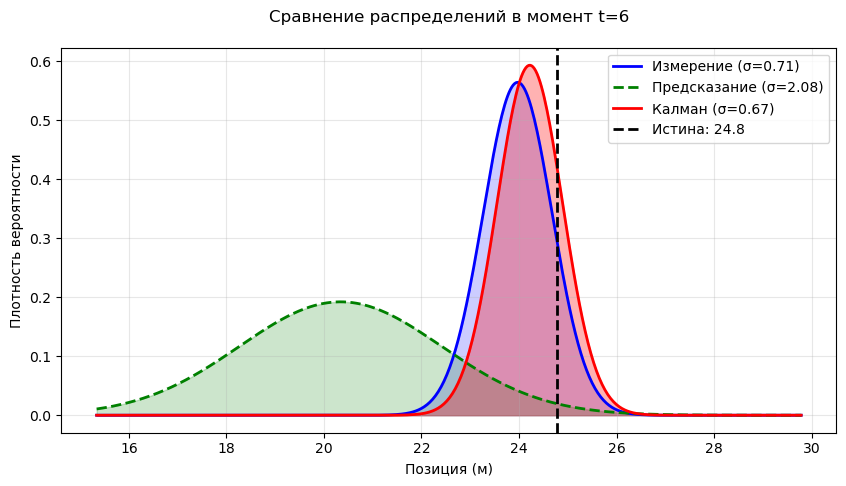

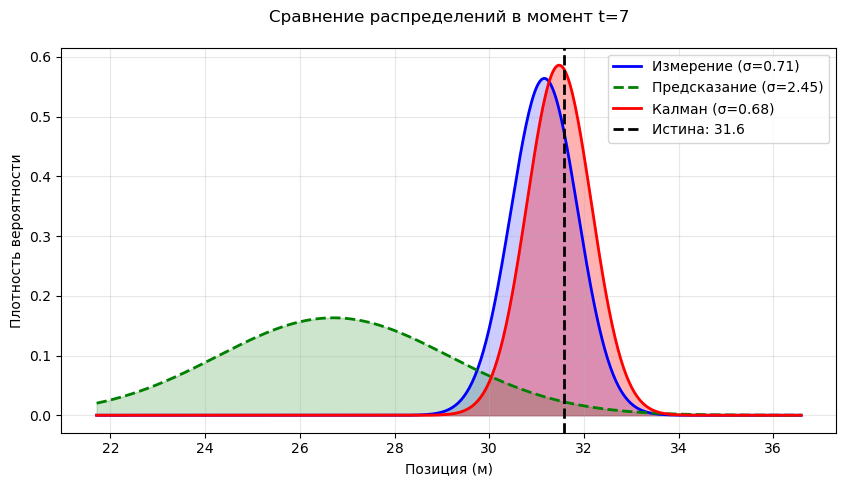

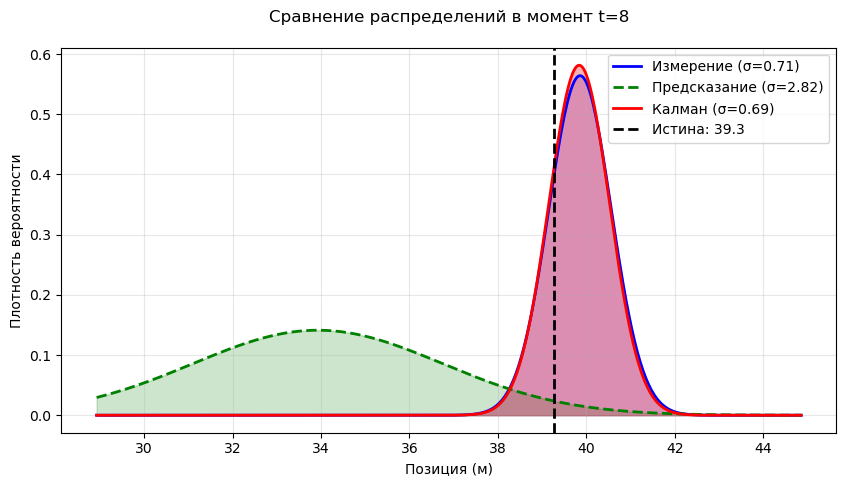

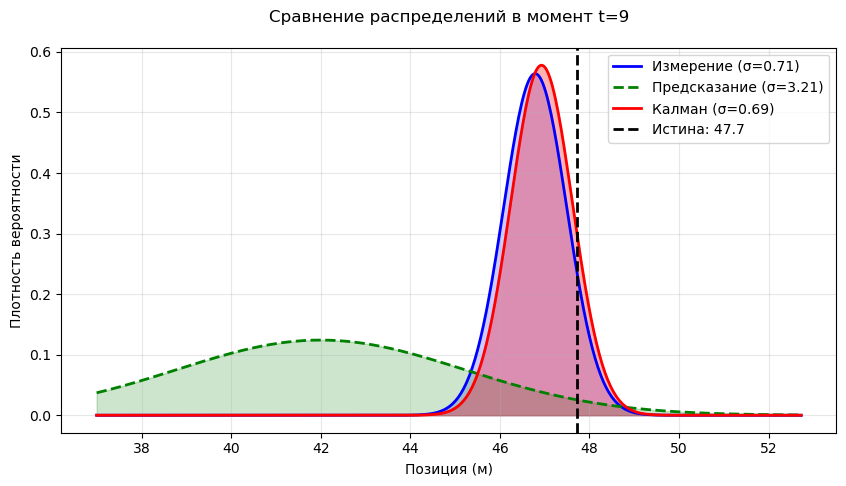

In [7]:
from scipy.stats import norm 

t_max = 10
for t in range(t_max):
    np.random.seed(42)
    kalman = KalmanFilter(mu0, cov0, u0, z0)
    res = kalman.simulate(A, B, C, Q, R, x_true, time_sec, fs, "uniform_accel", False)

    states = np.array([s[0] for s in res['states']])
    true_states = np.array([t[0] for t in res['true_states']])
    measurements = np.array([m[0] for m in res['measurements']])
    predictions = np.array([p[0] for p in res['predictions']])

    true_val = true_states[t]
    meas_val = measurements[t]
    pred_val = predictions[t]
    kalman_val = states[t]

    meas_std = np.sqrt(Q[0, 0])
    pred_std = np.sqrt(res['pred_covs'][t][0, 0])
    kalman_std = np.sqrt(res['covariances'][t][0, 0])

    x_min = min(true_val, meas_val, pred_val, kalman_val) - 5
    x_max = max(true_val, meas_val, pred_val, kalman_val) + 5
    x = np.linspace(x_min, x_max, 500)

    # Вычисляем плотности вероятности
    pdf_meas = norm.pdf(x, meas_val, meas_std)
    pdf_pred = norm.pdf(x, pred_val, pred_std)
    pdf_kalman = norm.pdf(x, kalman_val, kalman_std)

    plt.figure(figsize=(10, 5))

    plt.plot(x, pdf_meas, 'b-', linewidth=2, label=f'Измерение (σ={meas_std:.2f})')
    plt.fill_between(x, 0, pdf_meas, alpha=0.2, color='blue')

    plt.plot(x, pdf_pred, 'g--', linewidth=2, label=f'Предсказание (σ={pred_std:.2f})')
    plt.fill_between(x, 0, pdf_pred, alpha=0.2, color='green')

    plt.plot(x, pdf_kalman, 'r-', linewidth=2, label=f'Калман (σ={kalman_std:.2f})')
    plt.fill_between(x, 0, pdf_kalman, alpha=0.3, color='red')

    plt.axvline(true_val, color='black', linestyle='--', linewidth=2, label=f'Истина: {true_val:.1f}')

    plt.xlabel('Позиция (м)')
    plt.ylabel('Плотность вероятности')
    plt.title(f'Сравнение распределений в момент t={t}\n')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.show()


In [8]:
numbers = [2, 5, 8, 12]
result = 0

for n in numbers:
    if n % 2 == 0:
        result += n
    elif n > 10:
        result += 3
    else:
        result += 1

print(result)

23
